In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
X_train = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task1\train_data.csv').values
y_train = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task1\train_label.csv').values.squeeze()

X_test = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task1\test_data.csv').values
y_test = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task1\test_label.csv').values.squeeze()

X_val = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task1\val_data.csv').values
y_val = pd.read_csv(r'C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 1\DataSets\task1\val_label.csv').values.squeeze()

In [3]:
y_train = y_train.astype(int)
y_val   = y_val.astype(int)
y_test  = y_test.astype(int)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [5]:
#tanh(z)= (e^z - e^-z) / (e^z + e^-z)
def tanh(z):
    exp_pos = np.exp(z)
    exp_neg = np.exp(-z)
    output = (exp_pos - exp_neg) / (exp_pos + exp_neg)
    return output


#d/dz(tanh(z)) = 1 - tanh(z)^2
def tanh_derivative(a):
    square = a * a
    derivative = 1 - square
    return derivative

#softmax(z_i) = exp(z_i) / sum(exp(z_j)) for all j
def softmax(z):
    max_value = np.max(z)
    shifted_z = z - max_value
    exp_values = np.exp(shifted_z)
    total = np.sum(exp_values)
    probabilities = exp_values / total
    return probabilities

In [6]:
#Loss=-log(p_correct_class)
def cross_entropy(y_true, y_pred):
    return -np.log(y_pred[y_true] + 1e-9)

In [7]:
def initialize_weights(input_dim, output_dim, seed=42):
    np.random.seed(seed)
    W1 = np.random.randn(input_dim, 20) * 0.01
    b1 = np.zeros(20)

    W2 = np.random.randn(20, 10) * 0.01
    b2 = np.zeros(10)

    W3 = np.random.randn(10, output_dim) * 0.01
    b3 = np.zeros(output_dim)

    return W1, b1, W2, b2, W3, b3

In [8]:
def forward_backward(x, y, params):

    W1, b1, W2, b2, W3, b3 = params

    #FORWARD PASS
    z1 = np.dot(x, W1) + b1
    a1 = tanh(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = tanh(z2)

    z3 = np.dot(a2, W3) + b3
    y_hat = softmax(z3)

    loss = cross_entropy(y, y_hat)

    #BACKWARD PASS
    # Output layer error
    #dz3 = y_hat - y_true
    dz3 = y_hat.copy()
    dz3[y] = dz3[y] - 1

    # Gradients for W3 and b3
    dW3 = np.outer(a2, dz3)
    db3 = dz3

    # Backpropagate error to layer 2
    # da = W_next . dz_next
    # dz = da * (1 - a^2)
    da2 = np.dot(W3, dz3)
    tanh_grad2 = tanh_derivative(a2)
    dz2 = da2 * tanh_grad2

    # Gradients for W2 and b2
    dW2 = np.outer(a1, dz2)
    db2 = dz2

    # Backpropagate error to layer 1
    # da = W_next . dz_next
    # dz = da * (1 - a^2)
    da1 = np.dot(W2, dz2)
    tanh_grad1 = tanh_derivative(a1)
    dz1 = da1 * tanh_grad1

    # Gradients for W1 and b1
    dW1 = np.outer(x, dz1)
    db1 = dz1

    grads = (dW1, db1, dW2, db2, dW3, db3)

    return loss, grads

In [9]:
#W(m+1)= w(m) - lr * grad(m)

def sgd_update(params, grads, lr):
    updated_params = []
    
    for i in range(len(params)):
        new_param = params[i] - lr * grads[i]
        updated_params.append(new_param)
    
    return tuple(updated_params)

In [10]:
#grad(m)=grad^2(0)+grad^2(1)+....+grad^2(m-1)
# W = W - lr * grad / (sqrt(cache) + eps) eps=1e-8

def adagrad_update(params, grads, cache, lr, eps=1e-8):
    
    updated_params = []
    updated_cache = []
    
    for i in range(len(params)):
        new_cache = cache[i] + grads[i]**2
        new_param = params[i] - lr * grads[i] / (np.sqrt(new_cache) + eps)
        updated_params.append(new_param)
        updated_cache.append(new_cache)
    
    return tuple(updated_params), tuple(updated_cache)

In [11]:
#cache(m)=beta(chache(m-1))+(1-beta)grad^2(m)
#W = W - lr * grad / (sqrt(cache) + eps)

def rmsprop_update(params, grads, cache, lr, beta=0.9, eps=1e-8):
    new_params, new_cache = [], []
    for p, g, c in zip(params, grads, cache):
        c = beta * c + (1 - beta) * g**2
        p -= lr * g / (np.sqrt(c) + eps)
        new_params.append(p)
        new_cache.append(c)
    return tuple(new_params), tuple(new_cache)

In [12]:
# m = beta1 * m + (1 - beta1) * grad     # momentum
#v = beta2 * v + (1 - beta2) * grad^2   # RMSProp
# W = W - lr * m / (sqrt(v) + eps)

def adam_update(params, grads, m, v, lr, t, beta1=0.9, beta2=0.999, eps=1e-8):
    new_params, new_m, new_v = [], [], []
    for p, g, mi, vi in zip(params, grads, m, v):
        mi = beta1 * mi + (1 - beta1) * g
        vi = beta2 * vi + (1 - beta2) * (g**2)

        m_hat = mi / (1 - beta1**t)
        v_hat = vi / (1 - beta2**t)
        p -= lr * m_hat / (np.sqrt(v_hat) + eps)
        new_params.append(p)
        new_m.append(mi)
        new_v.append(vi)

    return tuple(new_params), tuple(new_m), tuple(new_v)

In [13]:
# v = - lr * grad + alpha * delta w(m-1)
# W = W + v
def momentum_update(params, grads, velocity, lr, alpha=0.9):

    updated_params = []
    updated_velocity = []

    for i in range(len(params)):

        v_new = alpha * velocity[i] - lr * grads[i]
        p_new = params[i] + v_new

        updated_params.append(p_new)
        updated_velocity.append(v_new)

    return tuple(updated_params), tuple(updated_velocity)

In [14]:
def train(optimizer="sgd", lr=0.01, eps=1e-4, max_epochs=200):

    input_dim = X_train.shape[1]
    num_classes = len(np.unique(y_train))

    params = initialize_weights(input_dim, num_classes)
    error_history = []

    # Initialize optimizer states using normal loops
    velocity = []
    cache = []
    m = []
    v = []

    for i in range(len(params)):
        velocity.append(np.zeros_like(params[i]))
        cache.append(np.zeros_like(params[i]))
        m.append(np.zeros_like(params[i]))
        v.append(np.zeros_like(params[i]))

    # Training loop
    for epoch in range(max_epochs):

        total_error = 0

        for i in range(len(X_train)):

            x = X_train[i]
            y = y_train[i]

            loss, grads = forward_backward(x, y, params)
            total_error = total_error + loss

            if optimizer == "sgd":
                params = sgd_update(params, grads, lr)

            elif optimizer == "momentum":
                params, velocity = momentum_update(params, grads, velocity, lr, 0.9)

            elif optimizer == "adagrad":
                params, cache = adagrad_update(params, grads, cache, lr)

            elif optimizer == "rmsprop":
                params, cache = rmsprop_update(params, grads, cache, lr)

            elif optimizer == "adam":
                params, m, v = adam_update(params, grads, m, v, lr, epoch + 1)

        avg_error = total_error / len(X_train)
        error_history.append(avg_error)

        if epoch > 0:
            difference = abs(error_history[epoch] - error_history[epoch - 1])
            if difference < eps:
                break

    return params, error_history, epoch + 1

In [15]:
def predict(X, params):
    preds = []

    W1, b1, W2, b2, W3, b3 = params

    for i in range(len(X)):

        x = X[i]

        z1 = np.dot(x, W1) + b1
        a1 = tanh(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = tanh(z2)

        z3 = np.dot(a2, W3) + b3
        y_hat = softmax(z3)

        predicted_class = np.argmax(y_hat)
        preds.append(predicted_class)

    return np.array(preds)

In [16]:
def evaluate(params):

    train_preds = predict(X_train, params)
    test_preds = predict(X_test, params)

    train_cm = confusion_matrix(y_train, train_preds)
    test_cm = confusion_matrix(y_test, test_preds)

    return train_cm, test_cm

In [17]:
def show_confusion_matrix(cm, title, ax):
    im = ax.imshow(cm)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    n = cm.shape[0]

    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(cm[i][j]),
                    ha="center", va="center")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


Optimizer: sgd


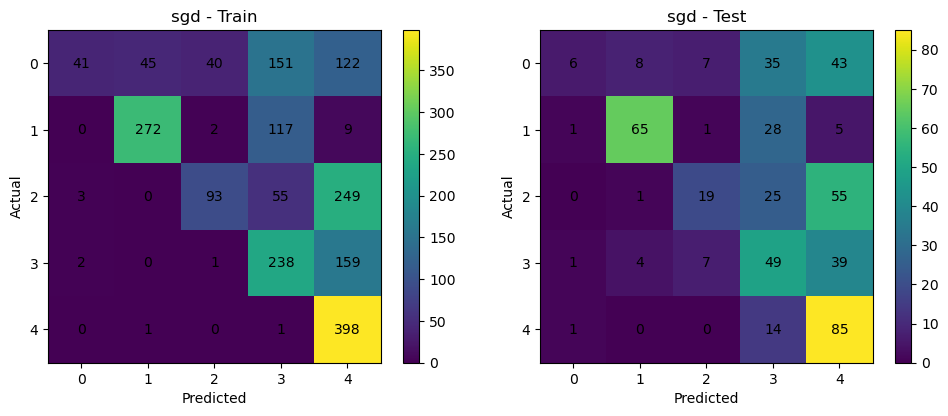


Optimizer: momentum


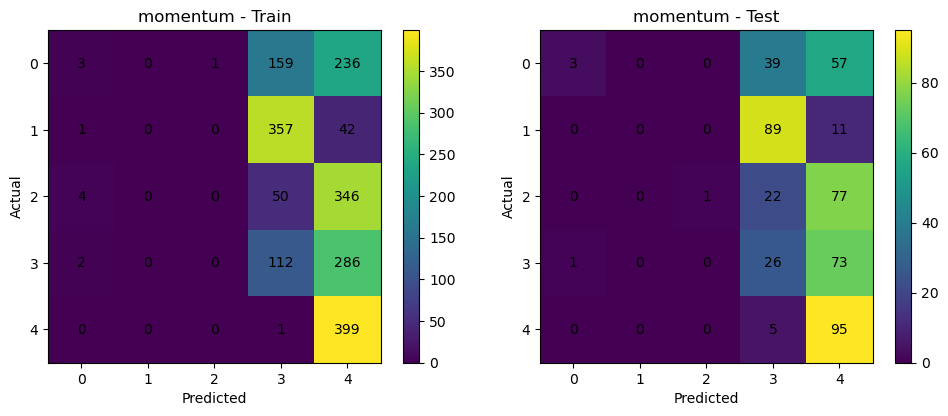


Optimizer: adagrad


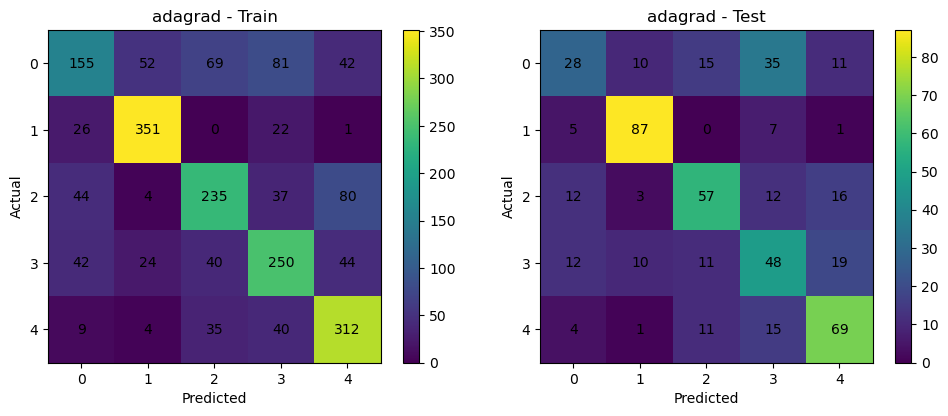


Optimizer: rmsprop


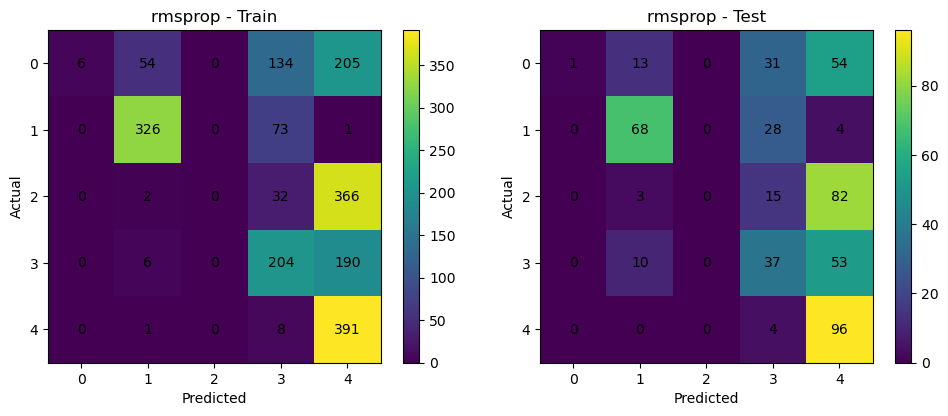


Optimizer: adam


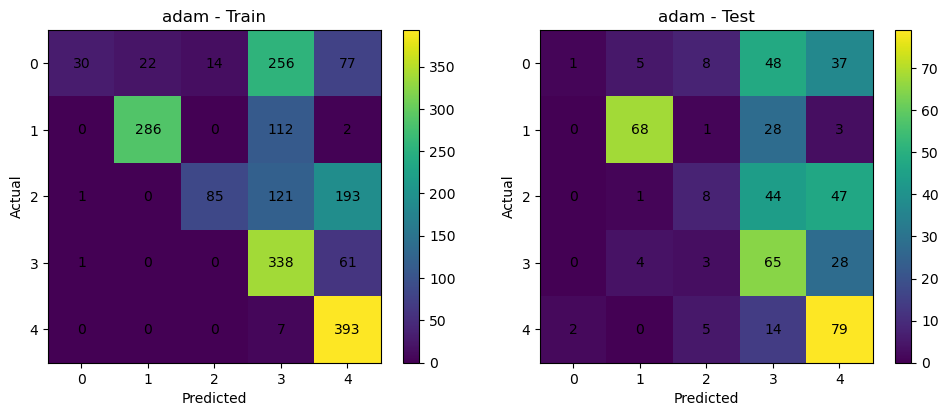

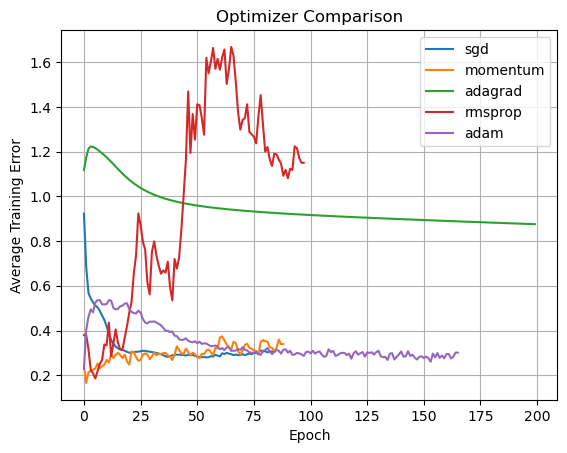

In [18]:
optimizers = ["sgd", "momentum", "adagrad", "rmsprop", "adam"]
results = {}

# ----------- TRAIN & SHOW CONFUSION MATRICES -----------
for opt in optimizers:

    print("\n==============================")
    print("Optimizer:", opt)
    print("==============================")

    params, error_hist, epochs = train(optimizer=opt, lr=0.01)
    cm_train, cm_test = evaluate(params)

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    show_confusion_matrix(cm_train, opt + " - Train", axes[0])
    show_confusion_matrix(cm_test, opt + " - Test", axes[1])

    plt.tight_layout()
    plt.show()

    # Store results
    results[opt] = {
        "errors": error_hist,
        "epochs": epochs,
        "cm_train": cm_train,
        "cm_test": cm_test
    }

# ----------- PLOT ALL OPTIMIZERS IN ONE GRAPH -----------
plt.figure()

for opt in optimizers:
    plt.plot(results[opt]["errors"], label=opt)

plt.xlabel("Epoch")
plt.ylabel("Average Training Error")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid()
plt.show()